In [33]:
# This file is mainly used for doing stream statistics.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from WFlib.utils.statistics import IQR_bound

def stream_numbers_fetch(db: pd.DataFrame, protocol: str, host: str):
    """
    Get the number of streams for the given protocol and host.
    """
    groups = db[(db['protocol'] == protocol) & (db['host'] == host)].groupby('id')
    stream_numbers = []
    for _, group in groups:
        stream_numbers.append(group.shape[0])
    return np.array(stream_numbers)

def select_features_by_host(npz_file, host_name, feature_key='hsdbs'):
    """
    Select features for a specific host from an npz file.
    
    Parameters:
    npz_file: The loaded npz file containing 'hosts', 'labels', and feature data
    host_name (str): The name of the host to select features for
    feature_key (str): The key name for the feature data in the npz file (default: 'hsdbs')
    
    Returns:
    tuple: (selected_features, selected_labels) - Features and labels for the specified host
    """
    hosts = npz_file['hosts']
    labels = npz_file['labels']
    features = npz_file[feature_key]
    
    # Find the index of the host in the hosts array
    host_indices = np.where(hosts == host_name)[0]
    
    if len(host_indices) == 0:
        raise ValueError(f"Host '{host_name}' not found in the dataset")
    
    # Get the label corresponding to this host (should be the same for all instances)
    host_label = labels[host_indices[0]]
    
    # Find all features where the label matches the host's label
    mask = labels == host_label
    selected_features = features[mask]
    selected_labels = labels[mask]
    
    return selected_features, selected_labels

def select_features_by_hosts(npz_file, host_names, feature_key='hsdbs'):
    """
    Select features for multiple hosts from an npz file.
    
    Parameters:
    npz_file: The loaded npz file containing 'hosts', 'labels', and feature data
    host_names (list): List of host names to select features for
    feature_key (str): The key name for the feature data in the npz file (default: 'hsdbs')
    
    Returns:
    tuple: (selected_features, selected_labels) - Features and labels for the specified hosts
    """
    hosts = npz_file['hosts']
    labels = npz_file['labels']
    features = npz_file[feature_key]
    
    # Find the labels corresponding to the requested hosts
    host_labels = []
    if isinstance(host_names, str):
        host_names = [host_names]
    for host_name in host_names:
        host_indices = np.where(hosts == host_name)[0]
        if len(host_indices) == 0:
            raise ValueError(f"Host '{host_name}' not found in the dataset")
        host_labels.append(host_indices.item())
    
    # Find all features where the label matches any of the requested host labels
    mask = (labels == host_labels)
    selected_features = features[mask]
    selected_labels = labels[mask]
    
    return selected_features, selected_labels

In [2]:
db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv")
hosts = db['host'].unique()
protocol = ["normal", "vmess"]

stream_numbers = dict()

for host in hosts:
    for p in protocol:
        stream_numbers[(host, p)] = stream_numbers_fetch(db, p, host)

In [3]:
# For each value of stream numbers, filter the outliers according to IQR.
for host in hosts:
    for p in protocol:
        lower_bound, upper_bound= IQR_bound(stream_numbers[(host, p)])
        stream_numbers[(host, p)] = stream_numbers[(host, p)][
            (stream_numbers[(host, p)] <= upper_bound) & (stream_numbers[(host, p)] >= lower_bound)
        ]

avg_stream_numbers = {key: np.mean(value) for key, value in stream_numbers.items()}
std_stream_numbers = {key: np.std(value) for key, value in stream_numbers.items()}

In [ ]:
dataset_path = "/data/exp/lxyu/Dataset/WF/datasets/shadowsocks_hsdbs.npz"
# db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv").query("protocol == 'vmess'")

npz_file = np.load(dataset_path)

In [42]:
# select_features, select_labels = select_features_by_hosts(npz_file, "www.ieee.org", feature_key='hsdbs')
# features = npz_file['hsdbs'].flatten()
# features = features[features != 0]
# hist, bins = np.histogram(features, bins=list(range(-10742511, 284954, 1000)))

# # Create a boolean mask where True indicates non-zero elements
# mask = (features != 0)
# # Find the first False (0) in each row
# first_zero_indices = np.argmax(~mask, axis=1)
# # If there's no 0 in a row, argmax will return 0, so we need to handle that case
# first_zero_indices[mask.all(axis=1)] = features.shape[1]  # Set to length of row if no zeros found

In [44]:
select_features, select_labels = select_features_by_hosts(npz_file, "archive.org", feature_key='hsdbs')
# Create a boolean mask where True indicates non-zero elements
mask = (select_features != 0)
# Find the first False (0) in each row
first_zero_indices = np.argmax(~mask, axis=1)
# If there's no 0 in a row, argmax will return 0, so we need to handle that case
first_zero_indices[mask.all(axis=1)] = select_features.shape[1]  # Set to length of row if no zeros found

In [5]:
db = db[db['host'] == "chrome.pictureknow.com"]

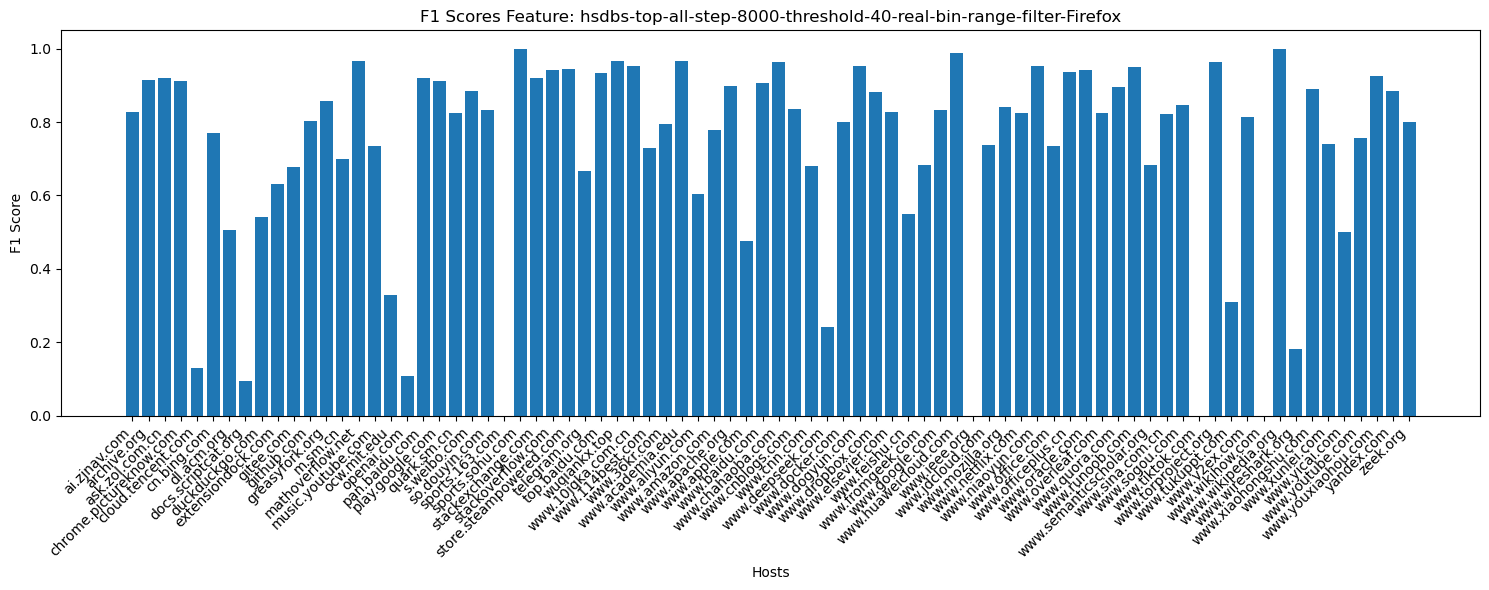

In [46]:
from WFlib.tools.capture import read_host_list
import matplotlib.pyplot as plt


f1_score = [0.8267,0.9157,0.9211,0.913,0.1304,0.7714,0.5063,0.0952,0.5412,0.6304,0.6783,0.8037,0.8571,0.6984,0.9655,0.7356,0.3284,0.1081,0.9189,0.9111,0.8235,0.8837,0.8333,0.0,1.0,0.9195,0.9412,0.9438,0.6667,0.9333,0.9655,0.9535,0.7294,0.7959,0.9663,0.6032,0.7778,0.8989,0.4752,0.9053,0.963,0.8367,0.6813,0.2414,0.8,0.9535,0.8831,0.8283,0.5484,0.6842,0.8333,0.988,0.0,0.7368,0.84,0.8247,0.9524,0.7339,0.9367,0.9425,0.8235,0.8966,0.9512,0.6835,0.8219,0.8478,0.0,0.963,0.3103,0.8132,0.0,1.0,0.1818,0.8889,0.7407,0.5,0.7579,0.9268,0.8842,0.8]
host_list_file = "host_list.txt"
hosts = sorted(read_host_list(host_list_file))

feature_name = "hsdbs-top-all-step-8000-threshold-40-real-bin-range-filter-Firefox"


# Create figure with larger size to accommodate labels
plt.figure(figsize=(15, 6))

# Create bar plot
plt.bar(range(len(hosts)), f1_score)

# Customize x-axis
plt.xticks(range(len(hosts)), hosts, rotation=45, ha='right')

# Add labels and title
plt.xlabel('Hosts')
plt.ylabel('F1 Score')
plt.title('F1 Scores Feature: ' + feature_name)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.savefig(feature_name + '.pdf', bbox_inches='tight', dpi=300, format='pdf')

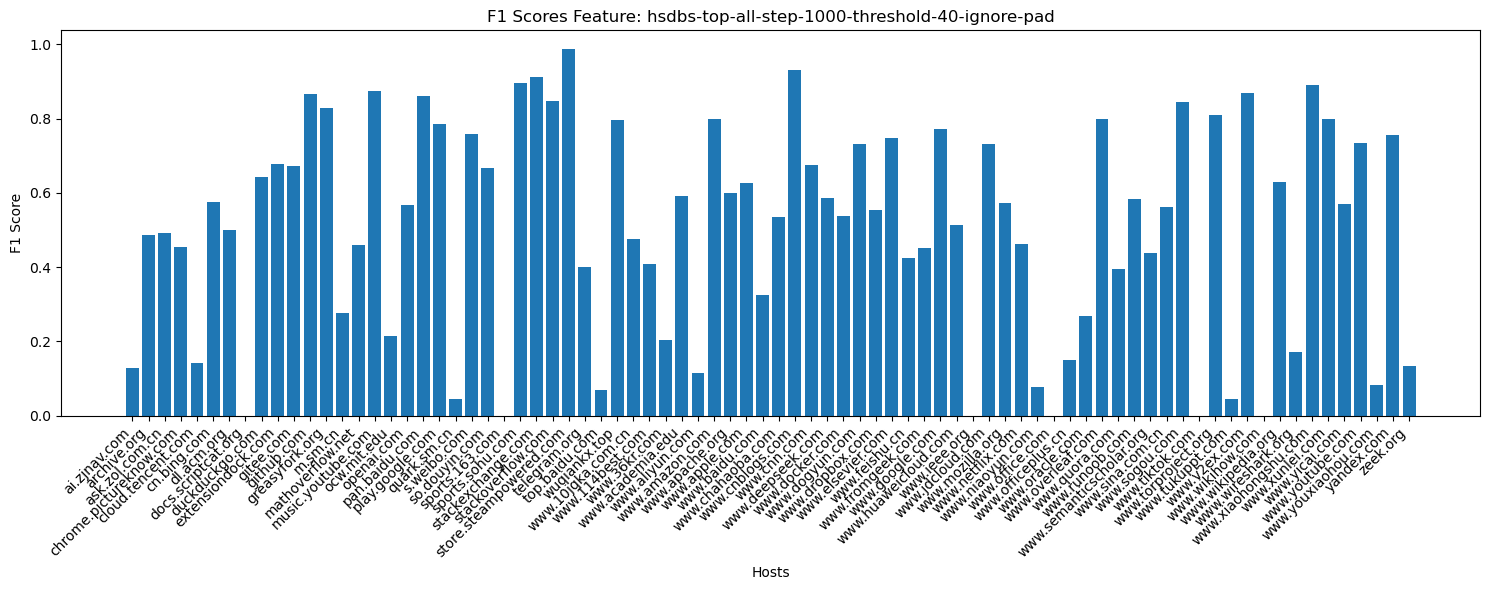

In [12]:
from WFlib.tools.capture import read_host_list
import matplotlib.pyplot as plt


f1_score = [0.6301,0.4222,0.6769,0.4091,0.3765,0.6667,0.5079,0.0702,0.6098,0.6667,0.7308,0.9195,0.4,0.6852,0.6852,0.8354,0.2817,0.5758,0.9268,0.7156,0.0444,0.9136,0.5273,0.0,0.9524,0.9545,0.5556,0.8974,0.5053,0.25,0.7843,0.65,0.3871,0.1091,0.7184,0.1935,0.8966,0.8182,0.4717,0.7416,0.4935,0.881,0.5962,0.3902,0.9398,0.9024,0.7547,0.5755,0.3636,0.5179,0.3333,0.7,0.0,0.4,0.7013,0.7467,0.4932,0.9176,0.6408,0.3103,0.7327,0.4407,0.6016,0.7586,0.8434,0.8632,0.0,0.95,0.3077,0.9318,0.0,0.5487,0.1695,0.8211,1.0,0.5139,0.6588,0.2807,0.7595,0.1319]
host_list_file = "host_list.txt"
hosts = sorted(read_host_list(host_list_file))




# Create figure with larger size to accommodate labels
plt.figure(figsize=(15, 6))

# Create bar plot
plt.bar(range(len(hosts)), f1_score)

# Customize x-axis
plt.xticks(range(len(hosts)), hosts, rotation=45, ha='right')

feature_name = "hsdbs-top-120-step-500-threshold-40-ignore-pad"

# Add labels and title
plt.xlabel('Hosts')
plt.ylabel('F1 Score')
plt.title('F1 Scores Feature: ' + feature_name)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.savefig('hsdbs-top-120-step-500-threshold-40-ignore-pad.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [77]:
import pandas as pd
from WFlib.tools.formatter import array_path
from WFlib.tools.extractor import NpzHSDBSExtractor
import numpy as np

extractor = NpzHSDBSExtractor(ignore_control_packets=True, threshold=60)

base_dir = "/data/exp/lxyu/Dataset/WF/firefox/140/VisualSeg/csv_db_extract/arrays"
protocols = ['vmess', 'shadowsocks']
stream_sizes = {p: [] for p in protocols}
sni = 'firefox-settings-attachments.cdn.mozilla.net'

db = pd.read_csv("/data/exp/lxyu/Dataset/WF/firefox/140/VisualSeg/csv_db_extract/database.csv").query(f"sni == '{sni}'")

db = db[['host', 'id', 'stream', 'transport', 'protocol']]
for protocol in protocols:
    proto_db = db[db['protocol'] == protocol]
    paths = proto_db.apply(lambda row: f'{base_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
    for path in paths:
        npz_file = np.load(path)
        bursts = extractor.single_stream_extract(npz_file)
        stream_sizes[protocol].append(sum([abs(size) for _, size in bursts]))

In [8]:
filtered_stream_sizes = {'vmess': [size for size in stream_sizes['vmess'] if 2000000 < size < 2200000], 'shadowsocks': [size for size in stream_sizes['shadowsocks'] if 2200000 < size < 2400000], 'normal': [size for size in stream_sizes['normal'] if 1800000 < size < 2400000]}

In [11]:
import pandas as pd
host = 'archive.org'
db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv").query(f"host == '{host}'")[['sni']]
snis = db['sni'].unique()

In [3]:
# This part, we analyze the split statistic of the H2 streams
import pandas as pd

def protocol_avg_avail_h2(protocol, db):
    """
    Given the protocol and database, compute the average avail_H2 number for each SNI.
    """
    protocol_avail_h2 = dict()
    protocol_db = db.query(f"protocol == '{protocol}'")
    for sni in protocol_db['SNI'].unique():
        protocol_avail_h2[sni] = protocol_db.query(f"SNI == '{sni}'")['avail_h2_avg'].mean()
    return protocol_avail_h2

db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/h2_stream_analysis/database.csv")
normal_avail_h2 = protocol_avg_avail_h2('normal', db)
vmess_avail_h2 = protocol_avg_avail_h2('vmess', db)
shadowsocks_avail_h2 = protocol_avg_avail_h2('shadowsocks', db)

In [8]:
vmess_split_degree = {k: vmess_avail_h2[k] / v for k, v in normal_avail_h2.items() if k in vmess_avail_h2 and v >= 1}
shadowsocks_split_degree = {k: shadowsocks_avail_h2[k] / v for k, v in normal_avail_h2.items() if k in shadowsocks_avail_h2 and v >= 1}

In [3]:
import pandas as pd
from WFlib.tools.formatter import array_path
import numpy as np
from tqdm import tqdm

def protocol_stream_length(protocol, db):
    """
    Given the protocol and database, compute the average stream length for each SNI.
    """
    protocol_stream_length = dict()
    base_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/arrays"
    protocol_db = db.query(f"protocol == '{protocol}'")
    for host in tqdm(protocol_db['host'].unique()):
        host_db = protocol_db.query(f"host == '{host}'")
        for sni in host_db['sni'].unique(): 
            sni_db = host_db.query(f"sni == '{sni}'")
            paths = sni_db.apply(lambda row: f'{base_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
            for path in paths:
                if (host, sni) in protocol_stream_length:
                    protocol_stream_length[(host, sni)].append(np.load(path)['direction'].shape[0])
                else:
                    protocol_stream_length[(host, sni)] = [np.load(path)['direction'].shape[0]]
    return protocol_stream_length

db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv")

normal_stream_length = protocol_stream_length('normal', db)
vmess_stream_length = protocol_stream_length('vmess', db)
shadowsocks_stream_length = protocol_stream_length('shadowsocks', db)

100%|██████████| 80/80 [01:29<00:00,  1.12s/it]


In [10]:
import pickle

# Store the dicts above
path_normal_stream_length = "normal_stream_length.pkl"
path_vmess_stream_length = "vmess_stream_length.pkl"
path_shadowsocks_stream_length = "shadowsocks_stream_length.pkl"

with open(path_normal_stream_length, 'wb') as f:
    pickle.dump(normal_stream_length, f)
with open(path_vmess_stream_length, 'wb') as f:
    pickle.dump(vmess_stream_length, f)
with open(path_shadowsocks_stream_length, 'wb') as f:
    pickle.dump(shadowsocks_stream_length, f)

In [9]:
sni_filter = {'firefox-settings-attachments.cdn.mozilla.net', 'firefox.settings.services.mozilla.com', 'content-signature-2.cdn.mozilla.net'}

normal_stream_length = {k: np.array(normal_stream_length[k]) for k in sorted(normal_stream_length.keys()) if k[1] not in sni_filter}
vmess_stream_length = {k: np.array(vmess_stream_length[k]) for k in sorted(vmess_stream_length.keys()) if k[1] not in sni_filter}
shadowsocks_stream_length = {k: np.array(shadowsocks_stream_length[k]) for k in sorted(shadowsocks_stream_length.keys()) if k[1] not in sni_filter}

In [ ]:
import pickle
path_normal_stream_length = "normal_stream_length.pkl"
path_vmess_stream_length = "vmess_stream_length.pkl"
path_shadowsocks_stream_length = "shadowsocks_stream_length.pkl"

with open(path_normal_stream_length, 'rb') as f:
    normal_stream_length = pickle.load(f)
with open(path_vmess_stream_length, 'rb') as f:
    vmess_stream_length = pickle.load(f)
with open(path_shadowsocks_stream_length, 'rb') as f:
    shadowsocks_stream_length = pickle.load(f)

In [69]:
# Filter out short streams
threshold = 200
filter_normal = {k: normal_stream_length[k] for k in sorted(normal_stream_length.keys()) if np.max(normal_stream_length[k]) > threshold}
filter_vmess = {k: vmess_stream_length[k] for k in sorted(vmess_stream_length.keys()) if np.max(vmess_stream_length[k]) > threshold}
filter_shadowsocks = {k: shadowsocks_stream_length[k] for k in sorted(shadowsocks_stream_length.keys()) if np.max(shadowsocks_stream_length[k]) > threshold}


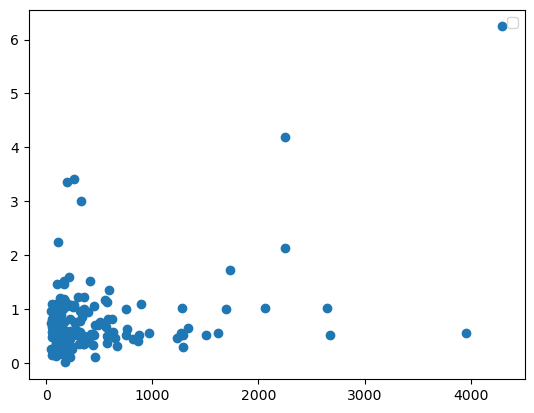

In [72]:
filter_proxy = filter_shadowsocks

avg_stream_length = []
split_degree = []
for k in filter_normal.keys():
    if k in filter_proxy and len(filter_proxy) > 200 and len(filter_normal[k]) > 200:
        split_degree.append(len(filter_proxy[k]) / len(filter_normal[k]))
        avg_stream_length.append(np.mean(filter_normal[k]))
        
split_degree = np.array(split_degree)
avg_stream_length = np.array(avg_stream_length)
# Plot the relationship between stream length and split degree
import matplotlib.pyplot as plt

plt.scatter(avg_stream_length[(avg_stream_length < 10000) & (avg_stream_length > 38)], split_degree[(avg_stream_length < 10000) & (avg_stream_length > 38)])
# Draw histogram of split degree
# plt.hist(split_degree, bins=100, alpha=0.5, label='Split Degree')
plt.legend()
plt.show()

In [73]:
print(len(split_degree[(split_degree < 1.0001) & (split_degree > 0.9)]) / len(split_degree))
print(len(split_degree[(1.0001 < split_degree) & (split_degree < 1.5)]) / len(split_degree[split_degree > 1.0001]))
print(len(split_degree[(1.5 < split_degree) & (split_degree < 2.5)]) / len(split_degree[split_degree > 1.0001]))
print(len(split_degree[(2.5 < split_degree) & (split_degree < 3.5)]) / len(split_degree[split_degree > 1.0001]))
print(len(split_degree[(3.5 < split_degree) & (split_degree < 4.5)]) / len(split_degree[split_degree > 1.0001]))
print(len(split_degree[(4.5 < split_degree) & (split_degree < 5.5)]) / len(split_degree[split_degree > 1.0001]))
print(len(split_degree[(5.5 < split_degree) & (split_degree < 6.5)]) / len(split_degree[split_degree > 1.0001]))
print(len(split_degree[(6.5 < split_degree)]) / len(split_degree[split_degree > 1.0001]))

0.04838709677419355
0.7555555555555555
0.13333333333333333
0.06666666666666667
0.022222222222222223
0.0
0.022222222222222223
0.0


In [66]:
# SNI wise split degree
sni_normal_stream_length = dict()
sni_vmess_stream_length = dict()
sni_shadowsocks_stream_length = dict()
for host, sni in normal_stream_length.keys():
    if sni not in sni_normal_stream_length:
        sni_normal_stream_length[sni] = []
    sni_normal_stream_length[sni].extend(normal_stream_length[(host, sni)])

for host, sni in vmess_stream_length.keys():
    if sni not in sni_vmess_stream_length:
        sni_vmess_stream_length[sni] = []
    sni_vmess_stream_length[sni].extend(vmess_stream_length[(host, sni)])

for host, sni in shadowsocks_stream_length.keys():
    if sni not in sni_shadowsocks_stream_length:
        sni_shadowsocks_stream_length[sni] = []
    sni_shadowsocks_stream_length[sni].extend(shadowsocks_stream_length[(host, sni)])

In [67]:
for sni in sni_normal_stream_length.keys():
    sni_normal_stream_length[sni] = np.array(sni_normal_stream_length[sni])

for sni in sni_vmess_stream_length.keys():
    sni_vmess_stream_length[sni] = np.array(sni_vmess_stream_length[sni])

for sni in sni_shadowsocks_stream_length.keys():
    sni_shadowsocks_stream_length[sni] = np.array(sni_shadowsocks_stream_length[sni])

In [68]:
# Filter out short streams
threshold = 38
sni_normal_stream_length = {k: sni_normal_stream_length[k][sni_normal_stream_length[k] > threshold] for k in sorted(sni_normal_stream_length.keys())}
sni_vmess_stream_length = {k: sni_vmess_stream_length[k][sni_vmess_stream_length[k] > threshold] for k in sorted(sni_vmess_stream_length.keys())}
sni_shadowsocks_stream_length = {k: sni_shadowsocks_stream_length[k][sni_shadowsocks_stream_length[k] > threshold] for k in sorted(sni_shadowsocks_stream_length.keys())}

In [1]:
# In this part, for each host, we find the SNI with the longest stream length.
import pickle
import numpy as np
path_normal_stream_length = "normal_stream_length.pkl"
path_vmess_stream_length = "vmess_stream_length.pkl"
path_shadowsocks_stream_length = "shadowsocks_stream_length.pkl"

with open(path_normal_stream_length, 'rb') as f:
    normal_stream_length = pickle.load(f)
with open(path_vmess_stream_length, 'rb') as f:
    vmess_stream_length = pickle.load(f)
with open(path_shadowsocks_stream_length, 'rb') as f:
    shadowsocks_stream_length = pickle.load(f)

In [11]:
def find_host_longest_sni(stream_length, threshold=190, max_k = 20):
    hosts = set(host for host, _ in stream_length)
    host_longest_sni = dict()
    for host in hosts:
        host_stream_longest_length = {sni: max(lengths) for (h, sni), lengths in stream_length.items() if host == h and len(lengths) > threshold}
        sni = max(host_stream_longest_length.items(), key=lambda x: x[1])[0]
        data = np.sort(stream_length[(host, sni)])[-max_k:]
        host_longest_sni[host] = (sni, data)
    return host_longest_sni

In [12]:
normal_host_longest_sni = find_host_longest_sni(normal_stream_length)
vmess_host_longest_sni = find_host_longest_sni(vmess_stream_length)
shadowsocks_host_longest_sni = find_host_longest_sni(shadowsocks_stream_length)

In [32]:
normal_vmess_split = {host: normal_host_longest_sni[host][1]/vmess_host_longest_sni[host][1] for host in sorted(normal_host_longest_sni)}
normal_shadowsocks_split = {host: normal_host_longest_sni[host][1]/shadowsocks_host_longest_sni[host][1] for host in sorted(normal_host_longest_sni)}
vmess_shadowsocks_split = {host: vmess_host_longest_sni[host][1]/shadowsocks_host_longest_sni[host][1] for host in sorted(vmess_host_longest_sni)}
normal_host_longest_sni_mean = {host: normal_host_longest_sni[host][1].mean() for host in sorted(normal_host_longest_sni)}


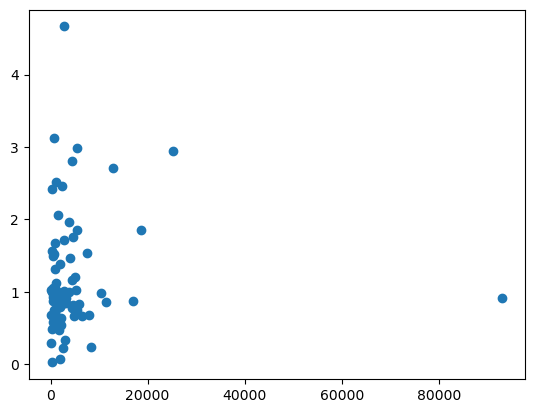

In [34]:
# Draw the relationship between the longest stream length and the split ratio of the longest stream length

import matplotlib.pyplot as plt
y = [v.mean() for v in normal_shadowsocks_split.values()]
x = [v for v in normal_host_longest_sni_mean.values()]

plt.scatter(x, y)
plt.show()

In [35]:
y

[0.8989440734093528,
 0.720620491655459,
 1.7499151749771162,
 0.7201679180066838,
 0.32869428308694915,
 0.8244205443028028,
 0.022390265012055547,
 0.9973415650979323,
 0.849854344072592,
 1.0470128205621574,
 2.9412805684797076,
 0.8194061113766941,
 3.1224717735170886,
 0.49157039517505713,
 1.5197031676741808,
 0.9918660679181762,
 0.6846948759302813,
 0.8646915031484468,
 0.9754117938135322,
 1.1555599133462768,
 1.0200483120393886,
 1.3774391023986745,
 4.66400763571125,
 1.8485083419137518,
 2.5203167707485297,
 1.5560085352430304,
 0.2849941078004611,
 0.6595679617793142,
 1.0108308996467554,
 0.5377190459942625,
 1.0008620428738904,
 0.5742763593892716,
 0.6326190382445708,
 2.464601111964414,
 0.9523474142364161,
 0.07075721611447953,
 1.2078420136662957,
 0.9001023154453277,
 0.2204577231376955,
 1.1209235674173619,
 0.9220735568129443,
 1.002833573675889,
 1.857491636254575,
 1.678750965932382,
 0.77727645282919,
 1.308495725039315,
 1.5305900494098568,
 0.9829938222581139